# Imports

In [1]:
import ee
import numpy as np
import math
import geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter

In [2]:
ee.Authenticate()


True

In [3]:

# Initialize Google Earth Engine
ee.Initialize(project='ee-gromero61')

In [4]:
nm_path = r"C:\Users\bsf31\Documents\data\NM\nm_vector.gpkg"
deming_gdf = gpd.read_file(nm_path, layer='deming')

In [5]:
deming_gdf

,OBJECTID,place,area,geometry
0,1,Deming,2.144544e+07,"MULTIPOLYGON (((804352.146 3576417.227, 804557..."


In [6]:
# Convert to Earth Engine geometry


ee_deming = geemap.geopandas_to_ee(deming_gdf).geometry()


In [7]:

# Create a geemap interactive map
Map = geemap.Map()

Map.addLayer(ee_deming, {}, "ee_deming")

Map.centerObject(ee_deming, zoom=10)


Map

Map(center=[32.2569386535637, -107.75242238385434], controls=(WidgetControl(options=['position', 'transparent_…

# Landsat Collection 2

In [8]:
# Function to scale the surface temperature band and convert to Fahrenheit
def scale_lst(image):
    lst_k = image.select('ST_B10').multiply(0.00341802).add(149.0)
    lst_f = lst_k.subtract(273.15).multiply(1.8).add(32)
    return image.addBands(lst_f.rename('LST_F'))

# Function to calculate NDVI
def calculate_ndvi(image):
    ndvi = image.normalizedDifference(['SR_B5', 'SR_B4'])
    return image.addBands(ndvi.rename('NDVI'))

# Function to calculate Fraction of Vegetation Cover
def calculate_fvc(image):
    fvc = image.select('NDVI').subtract(0.2).divide(0.3).pow(2).clamp(0, 1)
    return image.addBands(fvc.rename('FVC'))

# Function to calculate Emissivity
def calculate_emissivity(image):
    emissivity = image.select('FVC').multiply(0.0004).add(0.986)
    return image.addBands(emissivity.rename('Emissivity'))

# Define a function to clip each image to the ROI
def clip_to_region(image,roi):
    return image.clip(roi)


In [9]:
# Load the full Landsat collection
landsat_collection = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterDate('2019-04-01', '2024-11-01') \
    .filter(ee.Filter.calendarRange(5, 9, 'month')) \
    .filterBounds(ee_deming) \
    .filter(ee.Filter.lt('CLOUD_COVER', 9)) \
    .sort('system:time_start')



In [10]:
landsat_collection.size().getInfo()

77

In [11]:
""" 

# Load the Landsat 8 collection and filter images based on criteria
landsat_collection1 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterDate('2019-05-01', '2019-07-16') \
    .filter(ee.Filter.calendarRange(5, 9, 'month')) \
    .filterBounds(ee_lordsburg)\
    .filter(ee.Filter.lt('CLOUD_COVER', 9))  # Filter for images with less than 10% cloud cover
# Load the Landsat 8 collection and filter images based on criteria
landsat_collection2 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterDate('2019-07-17', '2022-09-01') \
    .filter(ee.Filter.calendarRange(5, 9, 'month')) \
    .filterBounds(ee_lordsburg)\
    .filter(ee.Filter.lt('CLOUD_COVER', 9))  # Filter for images with less than 10% cloud cover

landsat_collection3 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterDate('2022-09-02', '2024-09-15') \
    .filter(ee.Filter.calendarRange(5, 9, 'month')) \
    .filterBounds(ee_lordsburg)\
    .filter(ee.Filter.lt('CLOUD_COVER', 9))  # Filter for images with less than 10% cloud cover

# Load the Landsat 8 collection and filter images based on criteria
landsat_collection4 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterDate( '2024-09-16', '2024-11-01') \
    .filter(ee.Filter.calendarRange(5, 9, 'month')) \
    .filterBounds(ee_lordsburg)\
    .filter(ee.Filter.lt('CLOUD_COVER', 9))  # Filter for images with less than 10% cloud cover


# Combine the collections
combined_collection = landsat_collection1.merge(landsat_collection2).merge(landsat_collection3).merge(landsat_collection4).sort('system:time_start')

 """





' \n\n# Load the Landsat 8 collection and filter images based on criteria\nlandsat_collection1 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")     .filterDate(\'2019-05-01\', \'2019-07-16\')     .filter(ee.Filter.calendarRange(5, 9, \'month\'))     .filterBounds(ee_lordsburg)    .filter(ee.Filter.lt(\'CLOUD_COVER\', 9))  # Filter for images with less than 10% cloud cover\n# Load the Landsat 8 collection and filter images based on criteria\nlandsat_collection2 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")     .filterDate(\'2019-07-17\', \'2022-09-01\')     .filter(ee.Filter.calendarRange(5, 9, \'month\'))     .filterBounds(ee_lordsburg)    .filter(ee.Filter.lt(\'CLOUD_COVER\', 9))  # Filter for images with less than 10% cloud cover\n\nlandsat_collection3 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")     .filterDate(\'2022-09-02\', \'2024-09-15\')     .filter(ee.Filter.calendarRange(5, 9, \'month\'))     .filterBounds(ee_lordsburg)    .filter(ee.Filter.lt(\'CLOUD_COVER\', 9))  # Filter 

In [12]:
# Apply all processing steps
processed_collection = landsat_collection \
    .map(lambda image: image.clip(ee_deming)) \
    .map(scale_lst) \
    .map(calculate_ndvi) \
    .map(calculate_fvc) \
    .map(calculate_emissivity) 

In [13]:
# Get image dates
image_dates = processed_collection.aggregate_array('system:time_start') \
    .map(lambda t: ee.Date(t).format('YYYY-MM-dd')).getInfo()

print("Original Image Dates:", sorted(image_dates))

Original Image Dates: ['2019-05-13', '2019-05-29', '2019-05-29', '2019-06-30', '2019-06-30', '2019-07-16', '2019-08-01', '2019-08-01', '2019-08-17', '2019-09-02', '2019-09-02', '2019-09-18', '2019-09-18', '2020-05-15', '2020-05-15', '2020-05-31', '2020-05-31', '2020-06-16', '2020-06-16', '2020-08-03', '2020-08-03', '2020-08-19', '2020-08-19', '2020-09-04', '2020-09-04', '2020-09-20', '2020-09-20', '2021-05-02', '2021-05-18', '2021-06-03', '2021-06-19', '2021-06-19', '2021-07-21', '2021-07-21', '2021-08-06', '2021-08-06', '2021-08-22', '2021-08-22', '2021-09-07', '2021-09-07', '2022-05-05', '2022-05-05', '2022-05-21', '2022-05-21', '2022-06-06', '2022-06-06', '2022-07-08', '2022-07-08', '2022-07-24', '2022-08-09', '2022-09-10', '2022-09-10', '2023-05-08', '2023-05-08', '2023-05-24', '2023-05-24', '2023-06-25', '2023-06-25', '2023-07-11', '2023-07-27', '2023-07-27', '2023-08-12', '2023-09-29', '2023-09-29', '2024-05-10', '2024-05-26', '2024-05-26', '2024-06-11', '2024-06-11', '2024-07-13

In [14]:
# List of dates to remove Cloud Cover
dates_to_remove = ['2021-05-18', '2021-07-21']

# Remove specified dates (without using set)
filtered_dates = [date for date in image_dates if date not in dates_to_remove]


In [15]:



print("Filtered Image Dates:", sorted(filtered_dates))

# Count occurrences
counts = Counter(filtered_dates)

# Get duplicates BEFORE using set()
duplicates = [date for date, count in counts.items() if count > 1]

print("Duplicates BEFORE filtering:", duplicates)

Filtered Image Dates: ['2019-05-13', '2019-05-29', '2019-05-29', '2019-06-30', '2019-06-30', '2019-07-16', '2019-08-01', '2019-08-01', '2019-08-17', '2019-09-02', '2019-09-02', '2019-09-18', '2019-09-18', '2020-05-15', '2020-05-15', '2020-05-31', '2020-05-31', '2020-06-16', '2020-06-16', '2020-08-03', '2020-08-03', '2020-08-19', '2020-08-19', '2020-09-04', '2020-09-04', '2020-09-20', '2020-09-20', '2021-05-02', '2021-06-03', '2021-06-19', '2021-06-19', '2021-08-06', '2021-08-06', '2021-08-22', '2021-08-22', '2021-09-07', '2021-09-07', '2022-05-05', '2022-05-05', '2022-05-21', '2022-05-21', '2022-06-06', '2022-06-06', '2022-07-08', '2022-07-08', '2022-07-24', '2022-08-09', '2022-09-10', '2022-09-10', '2023-05-08', '2023-05-08', '2023-05-24', '2023-05-24', '2023-06-25', '2023-06-25', '2023-07-11', '2023-07-27', '2023-07-27', '2023-08-12', '2023-09-29', '2023-09-29', '2024-05-10', '2024-05-26', '2024-05-26', '2024-06-11', '2024-06-11', '2024-07-13', '2024-07-13', '2024-07-29', '2024-08-14

In [16]:
def get_cloud_mask(image):
    """Extracts cloud mask from QA_PIXEL bitmask"""
    qa_pixel = image.select('QA_PIXEL')
    
    # Bitwise operations to extract Cloud and Dilated Cloud mask (Bit 3 and Bit 1)
    cloud_mask = qa_pixel.bitwiseAnd(1 << 3).Or(qa_pixel.bitwiseAnd(1 << 1)).neq(0)
    
    # Compute cloud percentage over the ROI
    cloud_percentage = cloud_mask.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=ee_deming,
        scale=30,
        maxPixels=1e8
    ).get('QA_PIXEL')
    
    return image.set('ROI_CLOUD_COVER', cloud_percentage)

# Apply the cloud cover computation to the collection
processed_collection = processed_collection.map(get_cloud_mask)

# Extract computed cloud cover values
roi_cloud_covers = processed_collection.aggregate_array('ROI_CLOUD_COVER').getInfo()

# Print cloud cover within the study area
print("\nCloud cover within the clipped ROI:")
for date, roi_cloud in zip(image_dates, roi_cloud_covers):
    formatted_date = ee.Date(date).format("YYYY-MM-dd").getInfo()
    print(f"Date: {formatted_date}, ROI Cloud Cover: {roi_cloud:.2f}%")


Cloud cover within the clipped ROI:
Date: 2019-05-13, ROI Cloud Cover: 0.00%
Date: 2019-05-29, ROI Cloud Cover: 0.00%
Date: 2019-05-29, ROI Cloud Cover: 0.00%
Date: 2019-06-30, ROI Cloud Cover: 0.00%
Date: 2019-06-30, ROI Cloud Cover: 0.00%
Date: 2019-07-16, ROI Cloud Cover: 0.00%
Date: 2019-08-01, ROI Cloud Cover: 0.00%
Date: 2019-08-01, ROI Cloud Cover: 0.00%
Date: 2019-08-17, ROI Cloud Cover: 0.00%
Date: 2019-09-02, ROI Cloud Cover: 0.00%
Date: 2019-09-02, ROI Cloud Cover: 0.00%
Date: 2019-09-18, ROI Cloud Cover: 0.00%
Date: 2019-09-18, ROI Cloud Cover: 0.00%
Date: 2020-05-15, ROI Cloud Cover: 0.00%
Date: 2020-05-15, ROI Cloud Cover: 0.00%
Date: 2020-05-31, ROI Cloud Cover: 0.00%
Date: 2020-05-31, ROI Cloud Cover: 0.00%
Date: 2020-06-16, ROI Cloud Cover: 0.00%
Date: 2020-06-16, ROI Cloud Cover: 0.00%
Date: 2020-08-03, ROI Cloud Cover: 0.00%
Date: 2020-08-03, ROI Cloud Cover: 0.00%
Date: 2020-08-19, ROI Cloud Cover: 0.00%
Date: 2020-08-19, ROI Cloud Cover: 0.00%
Date: 2020-09-04, RO

In [17]:

# Find dates that are in list1 but NOT in list2
dates_in_list1_not_in_list2 = list(set(filtered_dates) - set(duplicates))

# Find dates that are in list2 but NOT in list1
dates_in_list2_not_in_list1 = list(set(duplicates) - set(filtered_dates))

print("Dates in image_dates but not in duplicates:", dates_in_list1_not_in_list2)
print("Dates in duplicates but not in image_dates:", dates_in_list2_not_in_list1)


Dates in image_dates but not in duplicates: ['2021-05-02', '2023-07-11', '2019-07-16', '2022-08-09', '2019-08-17', '2023-08-12', '2022-07-24', '2024-05-10', '2019-05-13', '2024-09-15', '2024-07-29', '2021-06-03']
Dates in duplicates but not in image_dates: []


In [18]:
combined_collection = ee.ImageCollection([])

In [19]:
for date in sorted(dates_in_list1_not_in_list2):
    print("Date:", date)

    # Convert the string date to an ee.Date() object
    ee_date = ee.Date(date)

    # Filter using the correct date format
    image = processed_collection.filterDate(ee_date, ee_date.advance(1, 'day'))  # Ensure proper filtering
    combined_collection = combined_collection.merge(image)
print(combined_collection.size().getInfo())

Date: 2019-05-13
Date: 2019-07-16
Date: 2019-08-17
Date: 2021-05-02
Date: 2021-06-03
Date: 2022-07-24
Date: 2022-08-09
Date: 2023-07-11
Date: 2023-08-12
Date: 2024-05-10
Date: 2024-07-29
Date: 2024-09-15
12


In [20]:
for date in duplicates:
    print("Date:", date)

    # Convert the string date to an ee.Date() object
    ee_date = ee.Date(date)

    # Filter using the correct date format
    duplicate_image = processed_collection.filterDate(ee_date, ee_date.advance(1, 'day'))  # Ensure proper filtering

    # Apply the cloud cover computation to the collection
    #int_coll = duplicate_image.map(get_cloud_mask)

    # Sort images in descending order by ROI_CLOUD_COVER and select the first (highest cloud cover)
    best_image = duplicate_image.sort('ROI_CLOUD_COVER', False).first()  # False = descending order
    combined_collection = combined_collection.merge(best_image)
print(combined_collection.size().getInfo())
""" 
    # Extract computed cloud cover values
    highest_cloud_cover = best_image.get('ROI_CLOUD_COVER').getInfo()  # Get the highest cloud cover value

    print(f"Highest Cloud Cover Image for {date}: {highest_cloud_cover}")
 """    

Date: 2019-05-29
Date: 2019-06-30
Date: 2019-08-01
Date: 2019-09-02
Date: 2019-09-18
Date: 2020-05-15
Date: 2020-05-31
Date: 2020-06-16
Date: 2020-08-03
Date: 2020-08-19
Date: 2020-09-04
Date: 2020-09-20
Date: 2021-06-19
Date: 2021-08-06
Date: 2021-08-22
Date: 2021-09-07
Date: 2022-05-05
Date: 2022-05-21
Date: 2022-06-06
Date: 2022-07-08
Date: 2022-09-10
Date: 2023-05-08
Date: 2023-05-24
Date: 2023-06-25
Date: 2023-07-27
Date: 2023-09-29
Date: 2024-05-26
Date: 2024-06-11
Date: 2024-07-13
Date: 2024-08-14
Date: 2024-08-30
43


' \n    # Extract computed cloud cover values\n    highest_cloud_cover = best_image.get(\'ROI_CLOUD_COVER\').getInfo()  # Get the highest cloud cover value\n\n    print(f"Highest Cloud Cover Image for {date}: {highest_cloud_cover}")\n '

# LST

In [21]:
# Function to extract LST values
def extract_lst(image):
    date = ee.Date(image.get('system:time_start')).format('YYYY-MM-dd')
    mean_lst = image.select('LST_F').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=ee_deming,
        scale=30
    ).get('LST_F')
    return ee.Feature(None, {'date': date, 'LST': mean_lst})

# Extract LST values
lst_values = combined_collection.map(extract_lst)


## Individual Date Mapping

In [22]:
# Applies scaling factors.
def apply_scale_factors(image):
  optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
  thermal_bands = image.select('ST_B.*').multiply(0.00341802).add(149.0)
  return image.addBands(optical_bands, None, True).addBands(
      thermal_bands, None, True
  )

# Define the target date
target_date = '2024-05-10'

# Filter the processed collection to only include the image from that date
filtered_collection = landsat_collection.filterDate(target_date, '2024-05-11')
first = filtered_collection.first()
last = filtered_collection.sort('system:time_start', False).first()
dataset = apply_scale_factors(first)
visualization = {
    'bands': ['SR_B4', 'SR_B3', 'SR_B2'],
    'min': 0.0,
    'max': 0.3,
}
vis_params = {'bands': ['LST_F'], 'palette': ['#0d0887', '#100788', '#130789', '#16078a', '#19068c', '#1b068d', '#1d068e', '#20068f', '#220690', '#240691', '#260591', '#280592', '#2a0593', '#2c0594', '#2e0595', '#2f0596', '#310597', '#330597', '#350498', '#370499', '#38049a', '#3a049a', '#3c049b', '#3e049c', '#3f049c', '#41049d', '#43039e', '#44039e', '#46039f', '#48039f', '#4903a0', '#4b03a1', '#4c02a1', '#4e02a2', '#5002a2', '#5102a3', '#5302a3', '#5502a4', '#5601a4', '#5801a4', '#5901a5', '#5b01a5', '#5c01a6', '#5e01a6', '#6001a6', '#6100a7', '#6300a7', '#6400a7', '#6600a7', '#6700a8', '#6900a8', '#6a00a8', '#6c00a8', '#6e00a8', '#6f00a8', '#7100a8', '#7201a8', '#7401a8', '#7501a8', '#7701a8', '#7801a8', '#7a02a8', '#7b02a8', '#7d03a8', '#7e03a8', '#8004a8', '#8104a7', '#8305a7', '#8405a7', '#8606a6', '#8707a6', '#8808a6', '#8a09a5', '#8b0aa5', '#8d0ba5', '#8e0ca4', '#8f0da4', '#910ea3', '#920fa3', '#9410a2', '#9511a1', '#9613a1', '#9814a0', '#99159f', '#9a169f', '#9c179e', '#9d189d', '#9e199d', '#a01a9c', '#a11b9b', '#a21d9a', '#a31e9a', '#a51f99', '#a62098', '#a72197', '#a82296', '#aa2395', '#ab2494', '#ac2694', '#ad2793', '#ae2892', '#b02991', '#b12a90', '#b22b8f', '#b32c8e', '#b42e8d', '#b52f8c', '#b6308b', '#b7318a', '#b83289', '#ba3388', '#bb3488', '#bc3587', '#bd3786', '#be3885', '#bf3984', '#c03a83', '#c13b82', '#c23c81', '#c33d80', '#c43e7f', '#c5407e', '#c6417d', '#c7427c', '#c8437b', '#c9447a', '#ca457a', '#cb4679', '#cc4778', '#cc4977', '#cd4a76', '#ce4b75', '#cf4c74', '#d04d73', '#d14e72', '#d24f71', '#d35171', '#d45270', '#d5536f', '#d5546e', '#d6556d', '#d7566c', '#d8576b', '#d9586a', '#da5a6a', '#da5b69', '#db5c68', '#dc5d67', '#dd5e66', '#de5f65', '#de6164', '#df6263', '#e06363', '#e16462', '#e26561', '#e26660', '#e3685f', '#e4695e', '#e56a5d', '#e56b5d', '#e66c5c', '#e76e5b', '#e76f5a', '#e87059', '#e97158', '#e97257', '#ea7457', '#eb7556', '#eb7655', '#ec7754', '#ed7953', '#ed7a52', '#ee7b51', '#ef7c51', '#ef7e50', '#f07f4f', '#f0804e', '#f1814d', '#f1834c', '#f2844b', '#f3854b', '#f3874a', '#f48849', '#f48948', '#f58b47', '#f58c46', '#f68d45', '#f68f44', '#f79044', '#f79143', '#f79342', '#f89441', '#f89540', '#f9973f', '#f9983e', '#f99a3e', '#fa9b3d', '#fa9c3c', '#fa9e3b', '#fb9f3a', '#fba139', '#fba238', '#fca338', '#fca537', '#fca636', '#fca835', '#fca934', '#fdab33', '#fdac33', '#fdae32', '#fdaf31', '#fdb130', '#fdb22f', '#fdb42f', '#fdb52e', '#feb72d', '#feb82c', '#feba2c', '#febb2b', '#febd2a', '#febe2a', '#fec029', '#fdc229', '#fdc328', '#fdc527', '#fdc627', '#fdc827', '#fdca26', '#fdcb26', '#fccd25', '#fcce25', '#fcd025', '#fcd225', '#fbd324', '#fbd524', '#fbd724', '#fad824', '#fada24', '#f9dc24', '#f9dd25', '#f8df25', '#f8e125', '#f7e225', '#f7e425', '#f6e626', '#f6e826', '#f5e926', '#f5eb27', '#f4ed27', '#f3ee27', '#f3f027', '#f2f227', '#f1f426', '#f1f525', '#f0f724', '#f0f921'], 'min': 65.14195312400005, 'max': 115.07512370000002}
m = geemap.Map()
m.center_object(ee_deming)
m.add_layer(dataset, visualization, 'True Color (432)')

#m.add_layer(dataset,vis_params, 'LST_F')
m

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

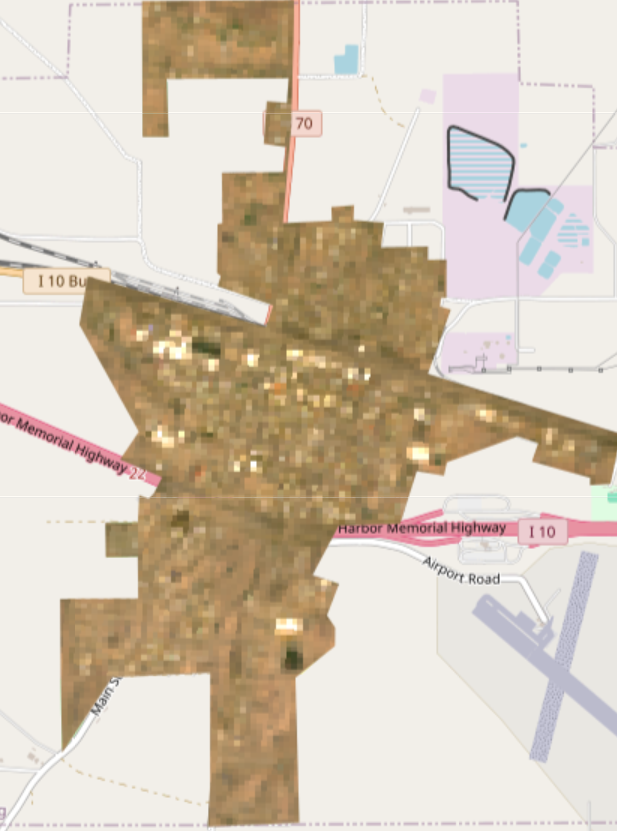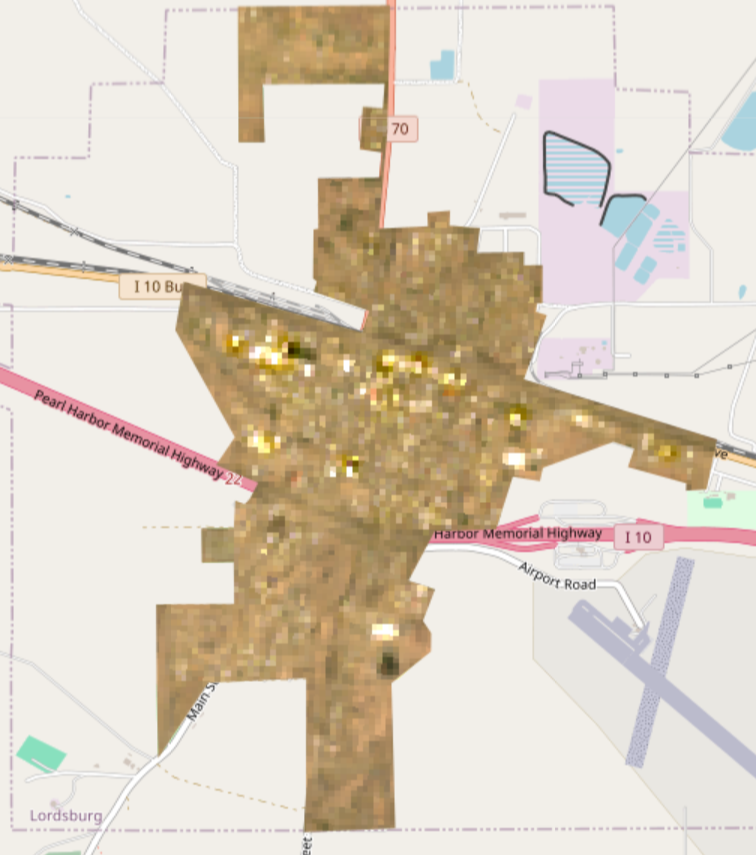

In [22]:
# Print results in chronological order
print("Date, Mean LST (°F)")

# Extract features
lst_list = lst_values.getInfo().get('features')

# Sort by date (ascending order)
sorted_lst_list = sorted(lst_list, key=lambda x: x['properties']['date'])

# Print in sorted order
for feature in sorted_lst_list:
    date = feature['properties']['date']
    lst = feature['properties']['LST']
    print(f"{date}, {lst:.2f}")

Date, Mean LST (°F)
2019-05-13, 99.47
2019-05-29, 116.54
2019-06-30, 133.38
2019-07-16, 137.51
2019-08-01, 121.81
2019-08-17, 123.02
2019-09-02, 127.52
2019-09-18, 107.65
2020-05-15, 119.24
2020-05-31, 126.77
2020-06-16, 128.01
2020-08-03, 136.75
2020-08-19, 128.85
2020-09-04, 125.24
2020-09-20, 110.49
2021-05-02, 111.91
2021-06-03, 131.98
2021-06-19, 135.32
2021-08-06, 129.85
2021-08-22, 134.38
2021-09-07, 121.34
2022-05-05, 118.95
2022-05-21, 121.14
2022-06-06, 131.44
2022-07-08, 136.48
2022-07-24, 128.29
2022-08-09, 110.56
2022-09-10, 118.75
2023-05-08, 119.01
2023-05-24, 123.02
2023-06-25, 132.29
2023-07-11, 134.34
2023-07-27, 138.63
2023-08-12, 122.86
2023-09-29, 115.40
2024-05-10, 111.77
2024-05-26, 119.25
2024-06-11, 132.72
2024-07-13, 126.05
2024-07-29, 104.92
2024-08-14, 128.87
2024-08-30, 111.68
2024-09-15, 123.19


In [23]:


# Print collection information
print(f"\nNumber of images: {combined_collection.size().getInfo()}")

# Print cloud cover information
cloud_covers = combined_collection.aggregate_array('CLOUD_COVER').getInfo()
dates = combined_collection.aggregate_array('system:time_start').getInfo()
dates =[pd.to_datetime(d, unit='ms').strftime('%Y-%m-%d') for d in dates]

print("\nCloud cover for each image:")
for date, cloud_cover in zip(dates, cloud_covers):
    print(f"{date}: {cloud_cover:.2f}%")


Number of images: 43

Cloud cover for each image:
2019-05-13: 7.73%
2019-07-16: 5.53%
2019-08-17: 6.91%
2021-05-02: 0.06%
2021-06-03: 5.08%
2022-07-24: 4.68%
2022-08-09: 6.29%
2023-07-11: 8.21%
2023-08-12: 4.24%
2024-05-10: 8.20%
2024-07-29: 2.29%
2024-09-15: 4.30%
2019-05-29: 7.42%
2019-06-30: 7.17%
2019-08-01: 7.59%
2019-09-02: 4.46%
2019-09-18: 7.68%
2020-05-15: 0.03%
2020-05-31: 2.03%
2020-06-16: 4.03%
2020-08-03: 0.02%
2020-08-19: 0.34%
2020-09-04: 0.61%
2020-09-20: 0.43%
2021-06-19: 0.91%
2021-08-06: 4.96%
2021-08-22: 7.42%
2021-09-07: 0.00%
2022-05-05: 0.01%
2022-05-21: 0.06%
2022-06-06: 0.01%
2022-07-08: 3.63%
2022-09-10: 3.26%
2023-05-08: 0.02%
2023-05-24: 0.14%
2023-06-25: 0.04%
2023-07-27: 3.43%
2023-09-29: 0.24%
2024-05-26: 0.06%
2024-06-11: 3.74%
2024-07-13: 0.65%
2024-08-14: 8.54%
2024-08-30: 7.45%


In [24]:
# Calculate the mean image across the entire collection
collection_mean = combined_collection.mean()

# Extract the mean LST over the lordsburg area
mean_lst = collection_mean.select('LST_F').reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=ee_deming,
    scale=30,
    maxPixels=1e8,
    bestEffort=True
).get('LST_F')

# Get the result as a Python object
mean_lst_value = mean_lst.getInfo()

print("Mean LST (°F) for the entire collection over Deming, NM:", mean_lst_value)


Mean LST (°F) for the entire collection over Deming, NM: 123.44269921663377


In [35]:
# Set up export parameters
export_task = ee.batch.Export.image.toDrive(
    image=collection_mean.select('LST_F'),  # Select the LST band
    description='deming_LST_Mean',
    folder='lst',  # Optional: specify a folder in Google Drive
    fileNamePrefix='deming_LST_Mean_Image',
    region=ee_deming,
    scale=30,
    crs='EPSG:4326',  # 'EPSG:32612',  # Use UTM Zone 12N to match the lordsburg vectors
    maxPixels=1e13
)

# Start the export task
export_task.start()
print("Exporting mean LST image to Google Drive...")

Exporting mean LST image to Google Drive...


In [26]:
vis_params = {'bands': ['LST_F'], 'palette': ['#000004', '#010005', '#010106', '#010108', '#020109', '#02020b', '#02020d', '#03030f', '#030312', '#040414', '#050416', '#060518', '#06051a', '#07061c', '#08071e', '#090720', '#0a0822', '#0b0924', '#0c0926', '#0d0a29', '#0e0b2b', '#100b2d', '#110c2f', '#120d31', '#130d34', '#140e36', '#150e38', '#160f3b', '#180f3d', '#19103f', '#1a1042', '#1c1044', '#1d1147', '#1e1149', '#20114b', '#21114e', '#221150', '#241253', '#251255', '#271258', '#29115a', '#2a115c', '#2c115f', '#2d1161', '#2f1163', '#311165', '#331067', '#341069', '#36106b', '#38106c', '#390f6e', '#3b0f70', '#3d0f71', '#3f0f72', '#400f74', '#420f75', '#440f76', '#451077', '#471078', '#491078', '#4a1079', '#4c117a', '#4e117b', '#4f127b', '#51127c', '#52137c', '#54137d', '#56147d', '#57157e', '#59157e', '#5a167e', '#5c167f', '#5d177f', '#5f187f', '#601880', '#621980', '#641a80', '#651a80', '#671b80', '#681c81', '#6a1c81', '#6b1d81', '#6d1d81', '#6e1e81', '#701f81', '#721f81', '#732081', '#752181', '#762181', '#782281', '#792282', '#7b2382', '#7c2382', '#7e2482', '#802582', '#812581', '#832681', '#842681', '#862781', '#882781', '#892881', '#8b2981', '#8c2981', '#8e2a81', '#902a81', '#912b81', '#932b80', '#942c80', '#962c80', '#982d80', '#992d80', '#9b2e7f', '#9c2e7f', '#9e2f7f', '#a02f7f', '#a1307e', '#a3307e', '#a5317e', '#a6317d', '#a8327d', '#aa337d', '#ab337c', '#ad347c', '#ae347b', '#b0357b', '#b2357b', '#b3367a', '#b5367a', '#b73779', '#b83779', '#ba3878', '#bc3978', '#bd3977', '#bf3a77', '#c03a76', '#c23b75', '#c43c75', '#c53c74', '#c73d73', '#c83e73', '#ca3e72', '#cc3f71', '#cd4071', '#cf4070', '#d0416f', '#d2426f', '#d3436e', '#d5446d', '#d6456c', '#d8456c', '#d9466b', '#db476a', '#dc4869', '#de4968', '#df4a68', '#e04c67', '#e24d66', '#e34e65', '#e44f64', '#e55064', '#e75263', '#e85362', '#e95462', '#ea5661', '#eb5760', '#ec5860', '#ed5a5f', '#ee5b5e', '#ef5d5e', '#f05f5e', '#f1605d', '#f2625d', '#f2645c', '#f3655c', '#f4675c', '#f4695c', '#f56b5c', '#f66c5c', '#f66e5c', '#f7705c', '#f7725c', '#f8745c', '#f8765c', '#f9785d', '#f9795d', '#f97b5d', '#fa7d5e', '#fa7f5e', '#fa815f', '#fb835f', '#fb8560', '#fb8761', '#fc8961', '#fc8a62', '#fc8c63', '#fc8e64', '#fc9065', '#fd9266', '#fd9467', '#fd9668', '#fd9869', '#fd9a6a', '#fd9b6b', '#fe9d6c', '#fe9f6d', '#fea16e', '#fea36f', '#fea571', '#fea772', '#fea973', '#feaa74', '#feac76', '#feae77', '#feb078', '#feb27a', '#feb47b', '#feb67c', '#feb77e', '#feb97f', '#febb81', '#febd82', '#febf84', '#fec185', '#fec287', '#fec488', '#fec68a', '#fec88c', '#feca8d', '#fecc8f', '#fecd90', '#fecf92', '#fed194', '#fed395', '#fed597', '#fed799', '#fed89a', '#fdda9c', '#fddc9e', '#fddea0', '#fde0a1', '#fde2a3', '#fde3a5', '#fde5a7', '#fde7a9', '#fde9aa', '#fdebac', '#fcecae', '#fceeb0', '#fcf0b2', '#fcf2b4', '#fcf4b6', '#fcf6b8', '#fcf7b9', '#fcf9bb', '#fcfbbd', '#fcfdbf'], 'min': 120.5238945518462, 'max': 131.59693843630777}
Map = geemap.Map()
Map.center_object(ee_deming, 12)
Map.addLayer(collection_mean,vis_params, 'collection_mean')
Map


Map(center=[32.2569386535637, -107.75242238385434], controls=(WidgetControl(options=['position', 'transparent_…

In [27]:
# Function to calculate per-image statistics for LST
def calculate_stats_per_image(image):
    stats = image.select('LST_F').reduceRegion(
        reducer=ee.Reducer.mean()
            .combine(ee.Reducer.min(), sharedInputs=True)
            .combine(ee.Reducer.max(), sharedInputs=True)
            .combine(ee.Reducer.stdDev(), sharedInputs=True),
        geometry=ee_deming,
        scale=30,
        maxPixels=1e8,
        bestEffort=True
    )
    return image.set(stats)

In [28]:
# Apply the function to each image in the collection to get per-image statistics
stats_per_image = combined_collection.map(calculate_stats_per_image)

In [29]:
# Extract individual statistics
dates = stats_per_image.aggregate_array('system:time_start').getInfo()
means = stats_per_image.aggregate_array('LST_F_mean').getInfo()
mins = stats_per_image.aggregate_array('LST_F_min').getInfo()
maxs = stats_per_image.aggregate_array('LST_F_max').getInfo()
std_devs = stats_per_image.aggregate_array('LST_F_stdDev').getInfo()


In [30]:
# Combine all data into a single list of tuples
data = list(zip(dates, means, mins, maxs, std_devs))

# Sort the list by date (ascending order)
sorted_data = sorted(data, key=lambda x: x[0])  # Sorting by the first element (timestamp)

# Print sorted per-image statistics
print("Per-image LST statistics:")
for date, mean, min_, max_, std_dev in sorted_data:
    formatted_date = ee.Date(date).format("YYYY-MM-dd").getInfo()
    print(f"Date: {formatted_date}, Mean LST: {mean}, Min LST: {min_}, Max LST: {max_}, StdDev LST: {std_dev}")


Per-image LST statistics:
Date: 2019-05-13, Mean LST: 99.46512652081192, Min LST: 86.74315591999999, Max LST: 114.94592254400004, StdDev LST: 3.673079817999471
Date: 2019-05-29, Mean LST: 116.54487439209034, Min LST: 98.17438200800002, Max LST: 126.41406324799996, StdDev LST: 3.4023449264152816
Date: 2019-06-30, Mean LST: 133.3799786075289, Min LST: 111.28522312399996, Max LST: 143.81315225600002, StdDev LST: 3.6906513628278423
Date: 2019-07-16, Mean LST: 137.51257700830712, Min LST: 113.95538034800005, Max LST: 147.4861565480001, StdDev LST: 4.163892272970018
Date: 2019-08-01, Mean LST: 121.81229160839467, Min LST: 97.71910174399999, Max LST: 134.83674813200005, StdDev LST: 5.822968887515896
Date: 2019-08-17, Mean LST: 123.02167260890948, Min LST: 102.41341041200008, Max LST: 131.231420636, StdDev LST: 3.5001778147552836
Date: 2019-09-02, Mean LST: 127.51549143979504, Min LST: 106.61552420000005, Max LST: 139.22343500000002, StdDev LST: 3.843379730640434
Date: 2019-09-18, Mean LST: 10

In [31]:
# Calculate overall statistics for the entire collection (min, max, stdDev)
collection_min = combined_collection.select('LST_F').reduce(ee.Reducer.min()).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=ee_deming,
    scale=30,
    maxPixels=1e8,
    bestEffort=True
).getInfo()

collection_max = combined_collection.select('LST_F').reduce(ee.Reducer.max()).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=ee_deming,
    scale=30,
    maxPixels=1e8,
    bestEffort=True
).getInfo()

collection_stddev = combined_collection.select('LST_F').reduce(ee.Reducer.stdDev()).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=ee_deming,
    scale=30,
    maxPixels=1e8,
    bestEffort=True
).getInfo()

# Print overall statistics
print("\nOverall Collection Statistics:")
print(f"Min LST: {collection_min}")
print(f"Max LST: {collection_max}")
print(f"StdDev LST: {collection_stddev}")


Overall Collection Statistics:
Min LST: {'LST_F_min': 96.35328175853907}
Max LST: {'LST_F_max': 139.44012250148734}
StdDev LST: {'LST_F_stdDev': 10.21927163486643}


Per-Image Standard Deviation: For each image, the standard deviation shows the variability of LST across the lordsburg area at a specific time. A low standard deviation means the temperatures are relatively uniform across the region, while a high standard deviation suggests there are large differences in temperature within that image, perhaps due to mixed land covers or varying microclimates.

Overall Collection Standard Deviation: When calculated across the entire collection, the standard deviation reflects how much the mean LST changes over time. A low value indicates that the temperatures are fairly stable across the whole period, while a high standard deviation suggests significant temperature changes over time, such as seasonal variations or extreme weather events.

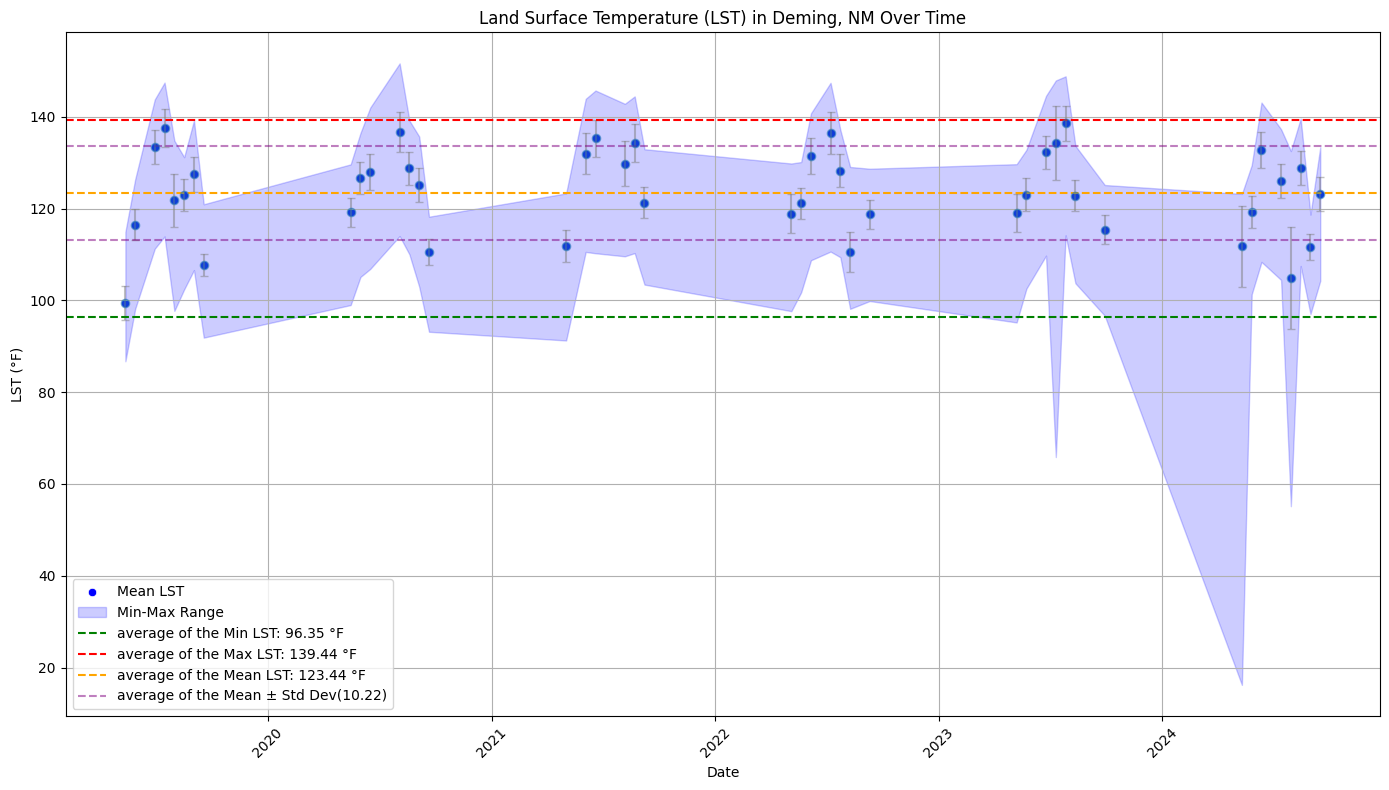

In [32]:
# Ensure dates are sorted before creating DataFrame
sorted_data = sorted(zip(dates, means, mins, maxs, std_devs), key=lambda x: x[0])

# Create DataFrame from sorted data
data = {
    'Date': [ee.Date(date).format("YYYY-MM-dd").getInfo() for date, _, _, _, _ in sorted_data],
    'Mean_LST': [mean for _, mean, _, _, _ in sorted_data],
    'Min_LST': [min_ for _, _, min_, _, _ in sorted_data],
    'Max_LST': [max_ for _, _, _, max_, _ in sorted_data],
    'StdDev_LST': [std_dev for _, _, _, _, std_dev in sorted_data]
}
df = pd.DataFrame(data)

# Convert 'Date' column to datetime format for proper sorting
df['Date'] = pd.to_datetime(df['Date'])

# Sort DataFrame by Date (although it's already sorted)
df = df.sort_values(by='Date')
# Overall collection statistics
overall_min =collection_min['LST_F_min']
overall_max =collection_max['LST_F_max']
overall_std_dev = collection_stddev['LST_F_stdDev']
overall_mean =  mean_lst_value

# Set up the scatter plot
plt.figure(figsize=(14, 8))
sns.scatterplot(x='Date', y='Mean_LST', data=df, color='blue', label='Mean LST')

# Add error bars for standard deviation
plt.errorbar(df['Date'], df['Mean_LST'], yerr=df['StdDev_LST'], fmt='o', ecolor='gray', alpha=0.5, capsize=3)

# Add shaded area for Min-Max range
plt.fill_between(df['Date'], df['Min_LST'], df['Max_LST'], color='blue', alpha=0.2, label='Min-Max Range')

# Add overall statistics as horizontal lines
plt.axhline(overall_min, color='green', linestyle='--', label=f'average of the Min LST: {overall_min:.2f} °F')
plt.axhline(overall_max, color='red', linestyle='--', label=f'average of the Max LST: {overall_max:.2f} °F')
plt.axhline(overall_mean, color='orange', linestyle='--', label=f'average of the Mean LST: {overall_mean:.2f} °F')
plt.axhline(overall_mean + overall_std_dev, color='purple', linestyle='--', alpha=0.5, label=f'average of the Mean ± Std Dev({overall_std_dev:.2f})')
plt.axhline(overall_mean - overall_std_dev, color='purple', linestyle='--', alpha=0.5)

# Customize the plot
plt.xlabel('Date')
plt.ylabel('LST (°F)')
plt.title('Land Surface Temperature (LST) in Deming, NM Over Time')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

# Function to aggregate LST for each date
def aggregate_lst_per_date(image_collection):
    """Groups images by date and averages LST values for each date."""
    distinct_dates = image_collection.aggregate_array('system:time_start').distinct()

    def compute_mean_lst(date):
        date = ee.Date(date)
        images_on_date = image_collection.filterDate(date, date.advance(1, 'day'))
        mean_image = images_on_date.mean().set('system:time_start', date)
        return mean_image

    return ee.ImageCollection(distinct_dates.map(compute_mean_lst))

# Apply the function to get a date-aggregated collection
aggregated_collection = aggregate_lst_per_date(processed_collection)

# Extract aggregated stats
image_dates = aggregated_collection.aggregate_array('system:time_start') \
    .map(lambda t: ee.Date(t).format('YYYY-MM-dd')).getInfo()

print("Aggregated Image Dates:")
print(image_dates)